In [1]:
import pandas as pd
import xclim
import xarray as xr
import xclim.indices as xci

In [2]:
fms_data = pd.read_excel("Nabouwalu_rainfall.xlsx")

In [3]:
fms_data.head()

,lsd,rain_24h,max_air_temp,min_air_temp,rel_humidity,wind_speed
0,NaT,mm,°c,°c,%,m/s
1,1990-01-01,0,28.5,24.4,63,5.144
2,1990-01-02,0,30,23.2,63,3.6008
3,1990-01-03,0,29.5,22.5,69,3.6008
4,1990-01-04,83.3,30.5,22.8,65,3.0864


In [4]:
fms_data = fms_data.drop(0)

In [5]:
# 1. Convert the date column to datetime (adjust 'Date' to your actual column name)
fms_data['Date'] = pd.to_datetime(fms_data['lsd'])

# 2. Set it as the index
fms_data = fms_data.set_index('Date')

# 3. Now you can extract the day of the year
fms_data['day_of_year'] = fms_data.index.dayofyear

# 4. Fill NaNs using the mean of that specific day across all years
fms_data['rain_24h'] = fms_data['rain_24h'].fillna(
    fms_data.groupby('day_of_year')['rain_24h'].transform('mean')
)

/tmp/ipykernel_1093/4206879906.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  fms_data['rain_24h'] = fms_data['rain_24h'].fillna(


In [6]:
fms_data

,lsd,rain_24h,max_air_temp,min_air_temp,rel_humidity,wind_speed,day_of_year
Date,,,,,,,
1990-01-01,1990-01-01,0.000000,28.5,24.4,63,5.144,1
1990-01-02,1990-01-02,0.000000,30,23.2,63,3.6008,2
1990-01-03,1990-01-03,0.000000,29.5,22.5,69,3.6008,3
1990-01-04,1990-01-04,83.300000,30.5,22.8,65,3.0864,4
1990-01-05,1990-01-05,22.500000,27.6,22.2,99,0,5
...,...,...,...,...,...,...,...
2025-04-26,2025-04-26,3.300000,31.2,24,69,NaN,116
2025-04-27,2025-04-27,7.300000,30.9,24.8,76,NaN,117
2025-04-28,2025-04-28,0.000000,30.9,25,73,NaN,118


In [7]:
# precipitation.to_csv("precipitation_nabouwalu.csv")

In [8]:
print(fms_data.rain_24h.mean)

<bound method Series.mean of Date
1990-01-01     0.000000
1990-01-02     0.000000
1990-01-03     0.000000
1990-01-04    83.300000
1990-01-05    22.500000
                ...    
2025-04-26     3.300000
2025-04-27     7.300000
2025-04-28     0.000000
2025-04-29     9.337931
2025-04-30     9.563333
Name: rain_24h, Length: 12904, dtype: float64>


<Axes: xlabel='Date'>

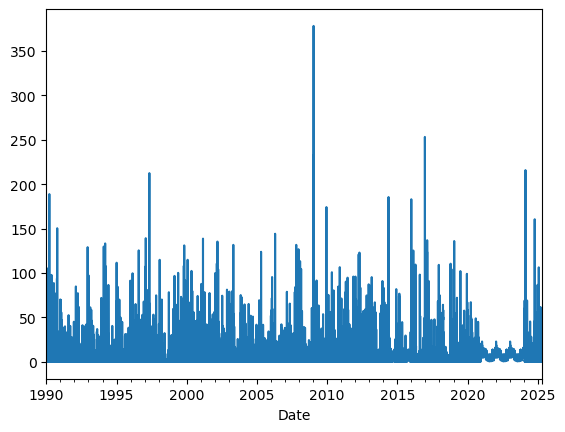

In [9]:
pr = fms_data.rain_24h
pr.plot()

In [10]:
# 2. Convert to Xarray
ds = fms_data.to_xarray()
ds = ds.apply(lambda x: x.astype(float) if x.dtype == 'O' else x)

In [11]:
ds

<xarray.Dataset> Size: 774kB
Dimensions:       (Date: 12904)
Coordinates:
  * Date          (Date) datetime64[ns] 103kB 1990-01-01 ... 2025-04-30
Data variables:
    lsd           (Date) datetime64[ns] 103kB 1990-01-01 ... 2025-04-30
    rain_24h      (Date) float64 103kB 0.0 0.0 0.0 83.3 ... 7.3 0.0 9.338 9.563
    max_air_temp  (Date) float64 103kB 28.5 30.0 29.5 30.5 ... 30.9 30.9 nan nan
    min_air_temp  (Date) float64 103kB 24.4 23.2 22.5 22.8 ... 25.0 24.5 nan
    rel_humidity  (Date) float64 103kB 63.0 63.0 69.0 65.0 ... 73.0 76.0 nan
    wind_speed    (Date) float64 103kB 5.144 3.601 3.601 3.086 ... nan nan nan
    day_of_year   (Date) int32 52kB 1 2 3 4 5 6 7 ... 115 116 117 118 119 120

In [12]:
# 3. CRITICAL: Add metadata (xclim needs this to understand the physics)
# Replace 'precip' with your actual column name
ds.rain_24h.attrs['units'] = 'mm/d'
ds.rain_24h.attrs['standard_name'] = 'precipitation_amount'

In [13]:
ds = ds.rename({'Date': 'time'})
ds = ds.rename({'rain_24h': 'pr'})

<xarray.DataArray 'pr' (time: 36)> Size: 288B
array([188.8     ,  69.9     , 129.1     ,  97.4     , 133.3     ,
       111.6     , 125.5     , 212.4     , 114.9     , 131.1     ,
       114.9     , 138.7     , 135.4     , 131.7     ,  65.2     ,
       123.9     , 144.2     , 131.7     , 113.3     , 378.      ,
       106.6     ,  96.      , 123.      ,  95.4     , 185.5     ,
       183.      , 253.1     , 136.9     , 110.5     , 136.      ,
        67.2     ,  22.959375,  22.959375,  22.959375, 215.8     ,
       106.4     ])
Coordinates:
  * time     (time) datetime64[ns] 288B 1990-01-01 1991-01-01 ... 2025-01-01
Attributes:
    units:          mm d-1
    standard_name:  precipitation_amount


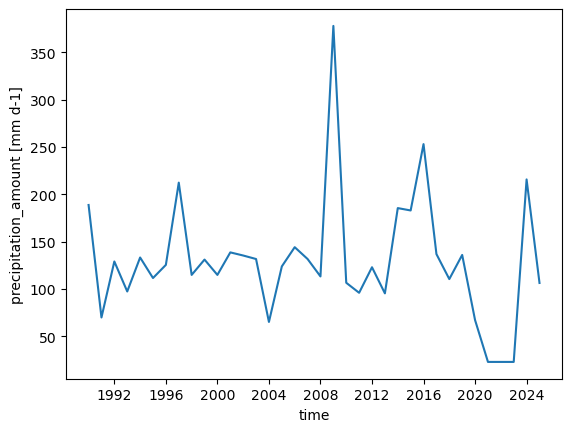

In [14]:
# 4. Run your xclim index
# freq="YS" means yearly (Year Start)
rx1day = xclim.indices.max_1day_precipitation_amount(ds.pr, freq="YS")

print(rx1day)

rx1day.plot()

In [15]:
# Note: SDII is 'simple_daily_intensity_index'
# sdii = xci.simple_daily_intensity_index(pr, freq="YS")